# Silent Spring

**Category:** Data Storytelling  
**Datasets:** animal-word-trends-silent-spring.csv (1,320 rows, 11 words)
+ sparrowhawk-eggshell-data.csv (58 rows)  
**Objective:** Build a historical narrative around two pivotal dates -
1944 (DDT's public release) and 1962 (Silent Spring's publication) -
using real word-frequency and eggshell-thickness data.

---

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/animal-word-trends-silent-spring.csv')
egg = pd.read_csv('../data/sparrowhawk-eggshell-data.csv')

df['word'].unique()

<StringArray>
[     'bedbug',      'condor',        'flea',         'fly',        'hawk',
       'louse',    'mosquito',      'osprey',   'peregrine',       'robin',
 'sparrowhawk']
Length: 11, dtype: str

## 1. Dataset Exploration

Exploring both datasets by examining their structure, dimensions, and
missing values before analysis. Understanding the available data helps
ensure that subsequent comparisons and visualizations are based on
complete and reliable information.

In [3]:
print("=== WORD TRENDS ===")
print("Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Year Range:", df['year'].min(), "-", df['year'].max())
print()

print("=== EGGSHELL DATA ===")
print("Shape:", egg.shape)
print("Missing Values:", egg.isnull().sum().sum())
print("Year Range:", egg['year'].min(), "-", egg['year'].max())

=== WORD TRENDS ===
Shape: (1320, 3)
Missing Values: 0
Year Range: 1900 - 2019

=== EGGSHELL DATA ===
Shape: (58, 2)
Missing Values: 0
Year Range: 1901 - 1967


## 2. Building Reusable Plotting Functions

Creating reusable plotting functions for insect and bird word trends.
Adding historical reference lines for **1944** (DDT introduction) and
**1962** (*Silent Spring* publication) provides important context for
interpreting changes in word frequency over time.

In [5]:
def plot_insect_word_trend(animal):
    trend = df.query('word == @animal')
    plt.figure(figsize=(5, 3))
    plt.plot(trend['year'], trend['frequency'], label=animal)
    plt.ylabel('Frequency per million')
    plt.title(f'Word usage for "{animal}" and the year DDT was made available')
    plt.axvline(1944, color='orange', ls='--')
    plt.show()

def plot_bird_word_trend(animal):
    trend = df.query('word == @animal')
    plt.figure(figsize=(5, 3))
    plt.plot(trend['year'], trend['frequency'], label=animal)
    plt.ylabel('Frequency per million')
    plt.title(f'Word usage for "{animal}" and the year Silent Spring published')
    plt.axvline(1962, color='orange', ls='--')
    plt.show()

## 3. Question 1 - Insect Words Around 1944

Looking across all five insect words together, checking for any visible
shift in trend right at 1944.

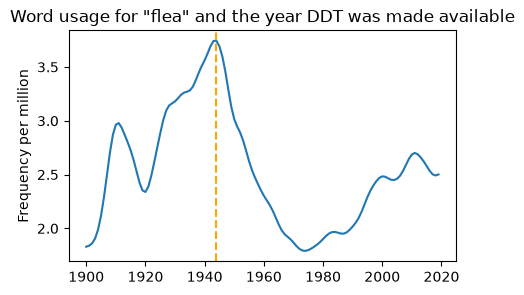

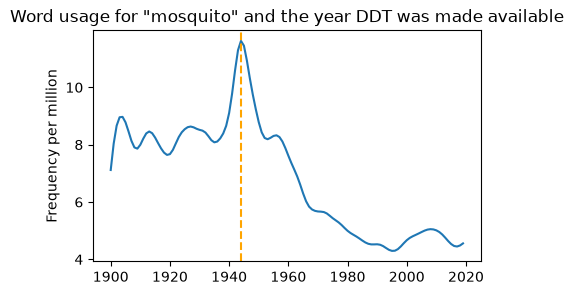

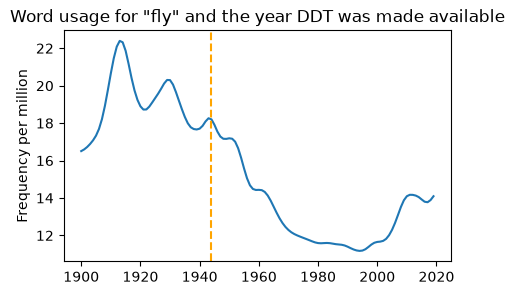

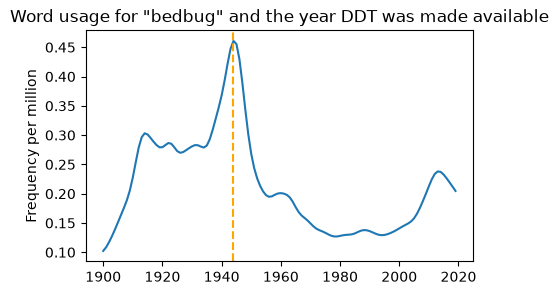

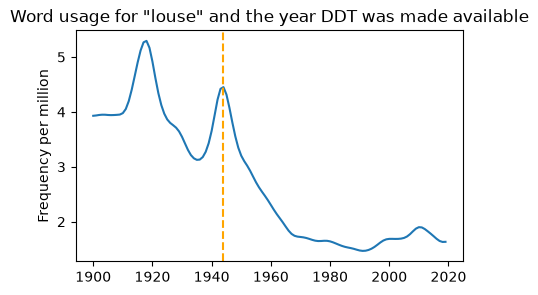

In [6]:
for word in ['flea', 'mosquito', 'fly', 'bedbug', 'louse']:
    plot_insect_word_trend(word)

## 4. Question 2 - Eggshell Thickness: Evaluating the "Harmless to Other Animals" Claim

Comparing sparrowhawk eggshell thickness before and after the
introduction of DDT to assess whether the available evidence is
consistent with the historical claim that the pesticide did not harm
other animals.

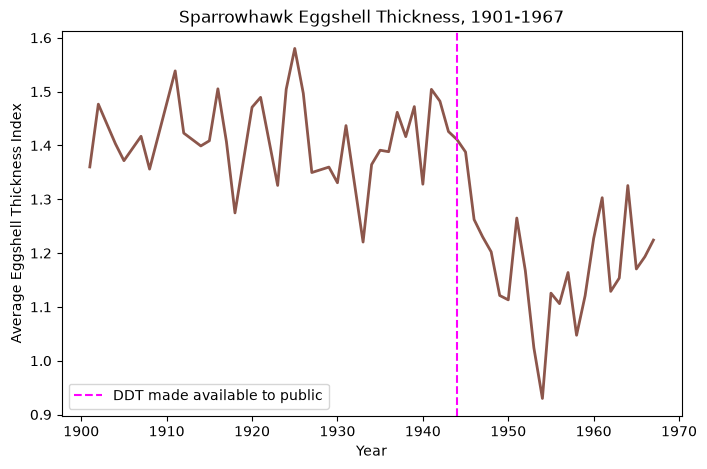

Chart Saved.


In [7]:
plt.figure(figsize=(8, 5))

plt.plot(egg['year'], egg['avg_thickness'], color='C5', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Average Eggshell Thickness Index')
plt.title('Sparrowhawk Eggshell Thickness, 1901-1967')
plt.axvline(1944, color='magenta', ls='--', label='DDT made available to public')
plt.legend()

plt.savefig('../images/plots/eggshell_thickness_decline.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart Saved.")

In [8]:
pre_1944 = egg[egg['year'] < 1944]['avg_thickness'].mean()
post_1944 = egg[egg['year'] >= 1944]['avg_thickness'].mean()
pct_change = (post_1944 - pre_1944) / pre_1944 * 100

print(f'Average thickness before 1944: {pre_1944:.3f}')
print(f'Average thickness from 1944 onward: {post_1944:.3f}')
print(f'Change: {pct_change:.1f}%')

Average thickness before 1944: 1.416
Average thickness from 1944 onward: 1.183
Change: -16.4%
